In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
import pickle

In [2]:
data = pd.read_csv('diabetes.csv')
data.columns = data.columns.str.strip().str.lower()
data.head()
print(f'Memuat data dari: cleaned_diabetes.csv')
print(f'Jumlah data: {data.shape[0]} Jumlah Kolom: {data.shape[1]}')

Memuat data dari: cleaned_diabetes.csv
Jumlah data: 768 Jumlah Kolom: 9


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## EDA

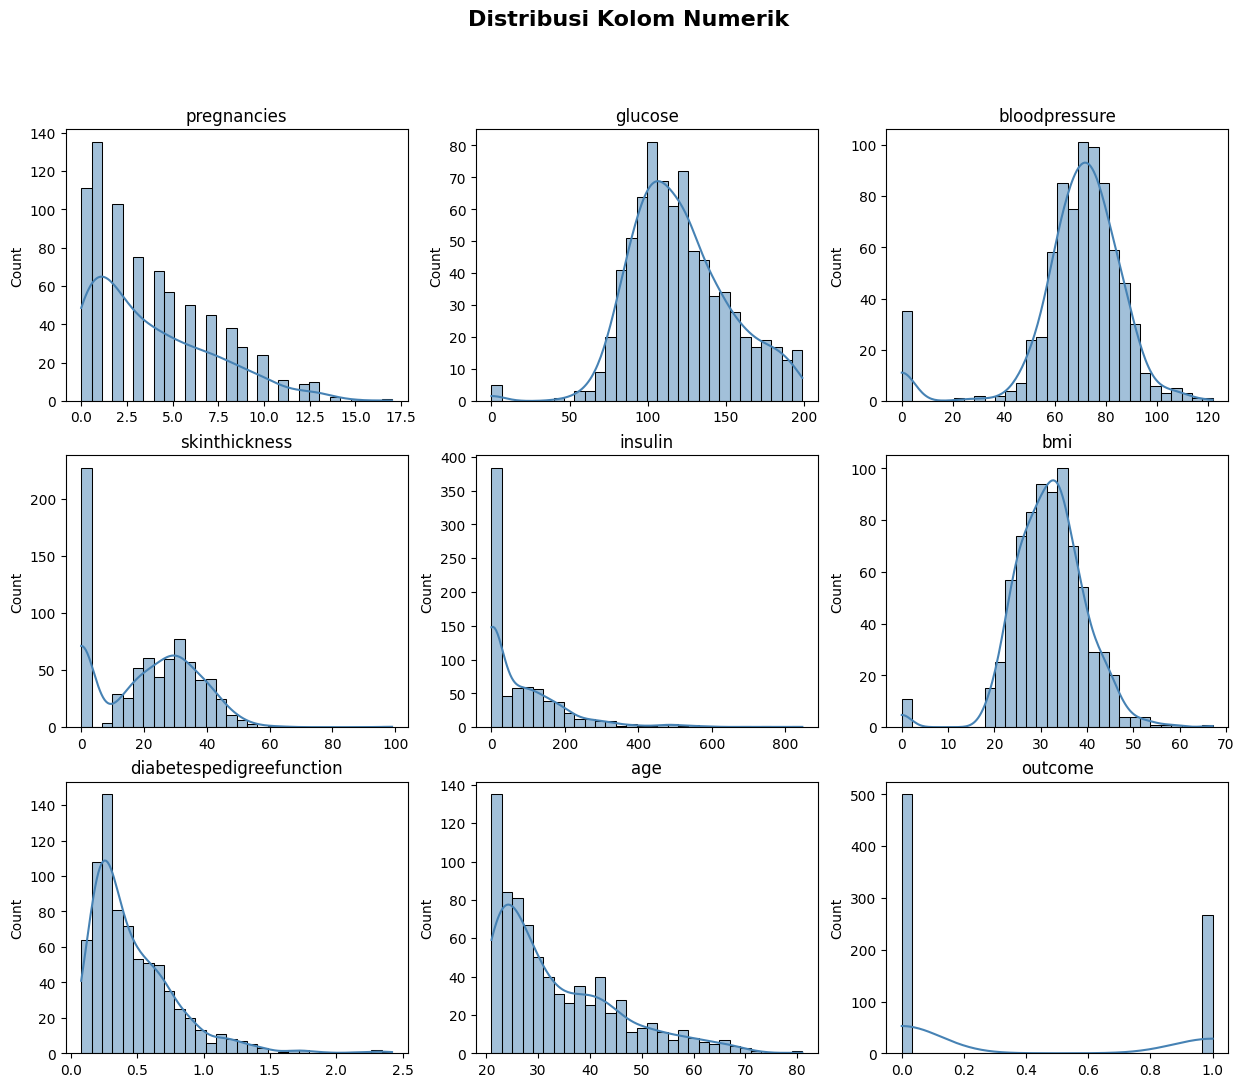

In [4]:
kolom_numerik    = data.select_dtypes(include=['number']).columns.tolist()
kolom_kategorikal = data.select_dtypes(include=['object']).columns.tolist()
if kolom_numerik:
    n_cols = 3
    n_rows = (len(kolom_numerik) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()
    fig.suptitle('Distribusi Kolom Numerik', fontsize=16, fontweight='bold')

    for i, col in enumerate(kolom_numerik):
        sns.histplot(data[col], bins=30, kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(col)
        axes[i].set_xlabel('')

        # sembunyikan subplot kosong
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

if kolom_kategorikal:
    n_cols = 3
    n_rows = (len(kolom_kategorikal) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    fig.suptitle('Distribusi Kolom Kategorikal', fontsize=16, fontweight='bold')

    for i, col in enumerate(kolom_kategorikal):
        order = data[col].value_counts().index
        sns.countplot(data=data, x=col, order=order, ax=axes[i], color='steelblue')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

## CLEANING

In [5]:
kolom_boleh_nol = ['pregnancies', 'diabetespedigreefunction', 'outcome']
for kolom in data.columns:
    if kolom not in kolom_boleh_nol:
        data[kolom] = data[kolom].replace(0, np.nan)
        print('Setelah mengganti 0 dengan NaN data yang memiliki nilai NaN:')
        print(data.isnull().sum())

Setelah mengganti 0 dengan NaN data yang memiliki nilai NaN:
pregnancies                 0
glucose                     5
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64
Setelah mengganti 0 dengan NaN data yang memiliki nilai NaN:
pregnancies                  0
glucose                      5
bloodpressure               35
skinthickness                0
insulin                      0
bmi                          0
diabetespedigreefunction     0
age                          0
outcome                      0
dtype: int64
Setelah mengganti 0 dengan NaN data yang memiliki nilai NaN:
pregnancies                   0
glucose                       5
bloodpressure                35
skinthickness               227
insulin                       0
bmi                           0
diabetespedigreefunction      0
age               

In [6]:
data.head(5)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [7]:
threshold = 20
data_persen = data.isnull().sum() / len(data) * 100
print(data_persen)
for col in data.columns:
    persen = data_persen[col]
    if persen == 0:
        continue
    elif persen > threshold:
        if data[col].dtype in ['object', 'category']:
            data[col] = data[col].fillna(data[col].mode()[0])
            print(f'Mengisi {col} dengan modus karena memiliki {persen:.2f}% data null')
        else:
            data[col] = data[col].fillna(data[col].median())
            print(f'Mengisi {col} dengan median karena memiliki {data_persen[col]:.2f}% data null')
    else:
        data = data.dropna(subset=[col])
        print(f'Menghapus baris dengan nilai null di {col} karena hanya memiliki {persen:.2f}% data null')  
print(data.isnull().sum())
missing = data.isnull().sum()
missing = missing[missing > 0]
    
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_persen = (missing / len(data) * 100).sort_values(ascending=False)
    sns.barplot(x=missing_persen.index, y=missing_persen.values, ax=ax, color='tomato')
    ax.set_title('Persentase Missing Value per Kolom', fontsize=13, fontweight='bold')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada missing value')

pregnancies                  0.000000
glucose                      0.651042
bloodpressure                4.557292
skinthickness               29.557292
insulin                     48.697917
bmi                          1.432292
diabetespedigreefunction     0.000000
age                          0.000000
outcome                      0.000000
dtype: float64
Menghapus baris dengan nilai null di glucose karena hanya memiliki 0.65% data null
Menghapus baris dengan nilai null di bloodpressure karena hanya memiliki 4.56% data null
Mengisi skinthickness dengan median karena memiliki 29.56% data null
Mengisi insulin dengan median karena memiliki 48.70% data null
Menghapus baris dengan nilai null di bmi karena hanya memiliki 1.43% data null
pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome             

In [8]:
print(f'Jumlah data duplikat: {data.duplicated().sum()}')
data = data.drop_duplicates()
print(f'Jumlah data setelah menghapus duplikat: {data.shape[0]}')

Jumlah data duplikat: 0
Jumlah data setelah menghapus duplikat: 724


========================= OUTLIER HANDLING =========================
Number of outliers in pregnancies: 4
Percentage of outliers in pregnancies: 0.55%
pregnancies: Memiliki 0.55% outlier, akan ditangani dengan metode clipping
pregnancies: Outlier telah dihapus karena hanya memiliki 0.55% outlier
 
Number of outliers in glucose: 0
Percentage of outliers in glucose: 0.00%
 glucose: Dilewati karena tidak memiliki outlier
 
Number of outliers in bloodpressure: 14
Percentage of outliers in bloodpressure: 1.94%
bloodpressure: Memiliki 1.94% outlier, akan ditangani dengan metode clipping
bloodpressure: Outlier telah dihapus karena hanya memiliki 1.94% outlier
 
Number of outliers in skinthickness: 51
Percentage of outliers in skinthickness: 7.22%
skinthickness: Memiliki 7.22% outlier, akan ditangani dengan metode clipping
skinthickness: Outlier telah dikoreksi dengan metode clipping
 
Number of outliers in insulin: 295
Percentage of outliers in insulin: 41.78%
insulin: Memiliki 41.78% outlier

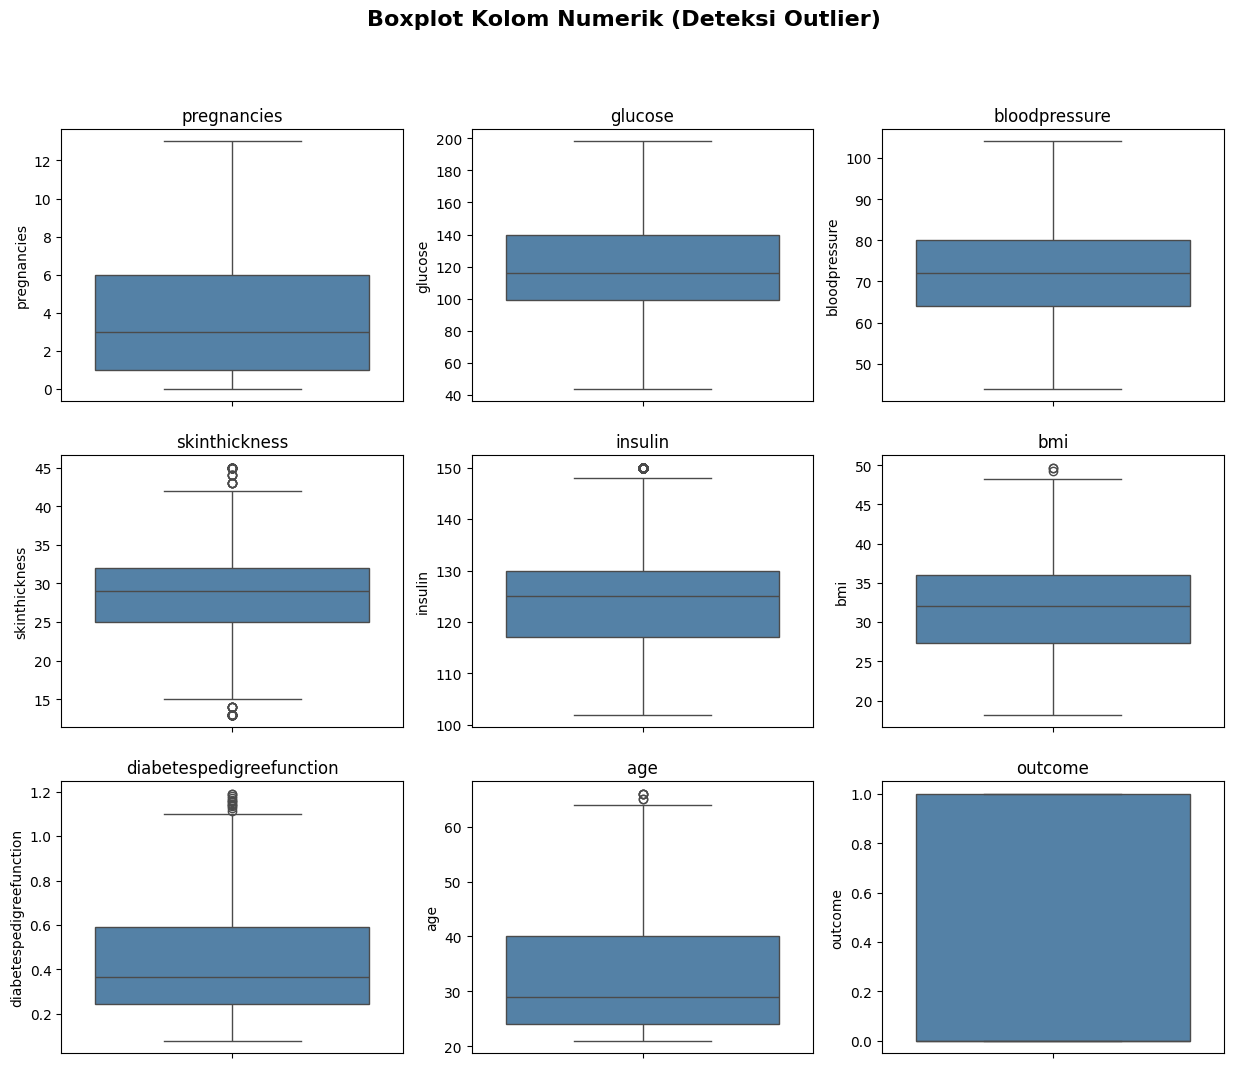

In [9]:
print('========================= OUTLIER HANDLING =========================')
jumlah_awal = len(data)

kolom_numerik = [col for col in data.columns if col != 'admission status']

for col in kolom_numerik:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5*iqr
    upper_limit = q3 + 1.5*iqr

    outlier = data[(data[col] < lower_limit) | (data[col] > upper_limit)].shape[0]
    outlier_persen = outlier / data.shape[0] * 100

    print(f"Number of outliers in {col}: {outlier}")
    print(f"Percentage of outliers in {col}: {outlier_persen:.2f}%")
    if outlier > 0:
        print(f'{col}: Memiliki {outlier_persen:.2f}% outlier, akan ditangani dengan metode clipping')
        if outlier_persen > 5:
            data[col] = data[col].clip(lower=lower_limit, upper=upper_limit)
            print(f'{col}: Outlier telah dikoreksi dengan metode clipping')
            print(' ')
        else:
            data = data.drop(data[(data[col] < lower_limit) | (data[col] > upper_limit)].index)
            print(f'{col}: Outlier telah dihapus karena hanya memiliki {outlier_persen:.2f}% outlier')
            print(' ')
    else:
        print(f' {col}: Dilewati karena tidak memiliki outlier')
        print(' ')

data = data.reset_index(drop=True)

if kolom_numerik:
    n_cols = 3
    n_rows = (len(kolom_numerik) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()
    fig.suptitle('Boxplot Kolom Numerik (Deteksi Outlier)', fontsize=16, fontweight='bold')

    for i, col in enumerate(kolom_numerik):
        sns.boxplot(y=data[col], ax=axes[i], color='steelblue')
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

print(f'Data Asli: {jumlah_awal}')
print(f'Data setelah preprocessing: {len(data)}')

In [10]:
print(data.skew().round(2))
kolom_skewed = [col for col in data.columns if col != 'outcome' and not col.endswith('_log')]

for col in kolom_skewed:
    skew = data[col].skew()
    if abs(skew) > 1:
        status = "Highly skewed"
    elif abs(skew) > 0.5:
        status = "Moderately skewed"
    else:
        status = "Normal/OK"
    print(f'{col:30}: {skew:.2f} → {status}')

kolom_highly_skewed = [col for col in kolom_skewed if abs(data[col].skew()) > 1]
print(f'Kolom yang akan ditransformasi: {kolom_highly_skewed}')

for col in kolom_highly_skewed:
    skew_before = data[col].skew()
    data[f'{col}_log'] = np.log1p(data[col])
    skew_after = data[f'{col}_log'].skew()
    print(f'{col}: Skewness {skew_before:.2f} → {skew_after:.2f}')

data = data.drop(columns=kolom_highly_skewed)


pregnancies                 0.83
glucose                     0.57
bloodpressure               0.04
skinthickness              -0.02
insulin                     0.10
bmi                         0.25
diabetespedigreefunction    0.93
age                         1.03
outcome                     0.74
dtype: float64
pregnancies                   : 0.83 → Moderately skewed
glucose                       : 0.57 → Moderately skewed
bloodpressure                 : 0.04 → Normal/OK
skinthickness                 : -0.02 → Normal/OK
insulin                       : 0.10 → Normal/OK
bmi                           : 0.25 → Normal/OK
diabetespedigreefunction      : 0.93 → Moderately skewed
age                           : 1.03 → Highly skewed
Kolom yang akan ditransformasi: ['age']
age: Skewness 1.03 → 0.58


In [11]:
data.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,outcome,age_log
0,6,148.0,72.0,35.0,125.0,33.6,0.627,1,3.931826
1,1,85.0,66.0,29.0,125.0,26.6,0.351,0,3.465736
2,8,183.0,64.0,29.0,125.0,23.3,0.672,1,3.496508
3,1,89.0,66.0,23.0,102.0,28.1,0.167,0,3.091042
4,5,116.0,74.0,29.0,125.0,25.6,0.201,0,3.433987


In [12]:
target = 'outcome'
y = data[target]
x = data.drop(columns=[target])

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
model = LogisticRegression(random_state=42)
model.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [16]:
x_pred = model.predict(x_test_scaled)
test_data_akurasi = accuracy_score(y_test, x_pred)
print(f'Akurasi pada data test: {test_data_akurasi:.4f}')

Akurasi pada data test: 0.7537


In [17]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi pada data testing: {accuracy:.4f}')

Akurasi pada data testing: 0.3657


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [18]:
input = (6, 148, 72, 35, 0, 33.6, 0.627, 50)

input_array = np.array(input).reshape(1, -1)

std_data = scaler.transform(input_array)
prediction = model.predict(std_data)

print(f'Prediksi untuk input {input}: {prediction[0]}')
if prediction[0] == 1:
    print('Prediksi: Pasien kemungkinan menderita diabetes')
else:
    print('Prediksi: Pasien kemungkinan tidak menderita diabetes')

Prediksi untuk input (6, 148, 72, 35, 0, 33.6, 0.627, 50): 1
Prediksi: Pasien kemungkinan menderita diabetes


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
filename = 'diabetes_model.sav'
pickle.dump(model, open(filename, 'wb'))
pickle.dump(scaler, open('scaler.sav', 'wb'))